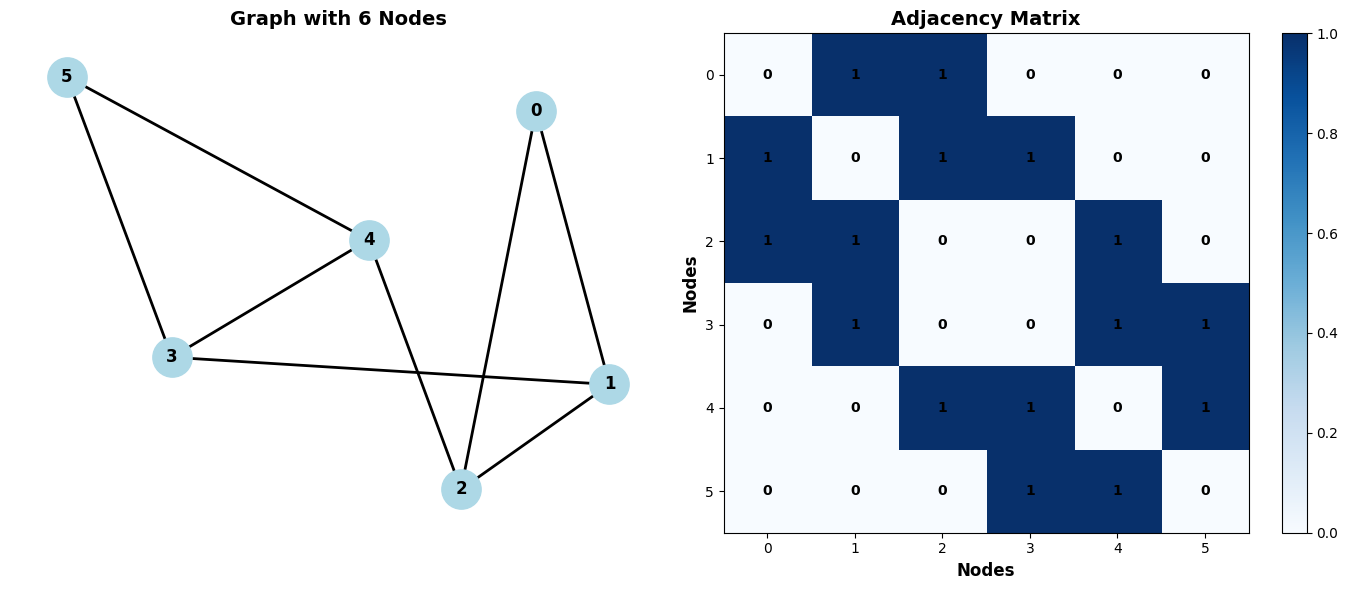

Adjacency Matrix:
[[0 1 1 0 0 0]
 [1 0 1 1 0 0]
 [1 1 0 0 1 0]
 [0 1 0 0 1 1]
 [0 0 1 1 0 1]
 [0 0 0 1 1 0]]


In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Create a graph with 6 nodes
G = nx.Graph()
G.add_nodes_from([0, 1, 2, 3, 4, 5])

# Add edges
edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4), (3, 5), (4, 5)]
G.add_edges_from(edges)

# Get the adjacency matrix
adj_matrix = nx.adjacency_matrix(G).todense()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Draw the graph
pos = nx.spring_layout(G, seed=42, k=2, iterations=50)
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800, ax=ax1)
nx.draw_networkx_edges(G, pos, width=2, ax=ax1)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax1)
ax1.set_title('Graph with 6 Nodes', fontsize=14, fontweight='bold')
ax1.axis('off')

# Draw the adjacency matrix
im = ax2.imshow(adj_matrix, cmap='Blues', aspect='auto')
ax2.set_xticks(range(6))
ax2.set_yticks(range(6))
ax2.set_xticklabels(range(6))
ax2.set_yticklabels(range(6))
ax2.set_xlabel('Nodes', fontsize=12, fontweight='bold')
ax2.set_ylabel('Nodes', fontsize=12, fontweight='bold')
ax2.set_title('Adjacency Matrix', fontsize=14, fontweight='bold')

# Add values to the matrix
for i in range(6):
    for j in range(6):
        text = ax2.text(j, i, int(adj_matrix[i, j]),
                       ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=ax2)
plt.tight_layout()
plt.savefig('./images/Practice0/graph_structure.png', dpi=400, bbox_inches='tight')
plt.show()

print("Adjacency Matrix:")
print(adj_matrix)

Number of nodes: 200
Number of edges: 1608


/var/folders/mz/h7lyhbx179g0m6677zcjjdbc0000gn/T/ipykernel_54185/2581387226.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


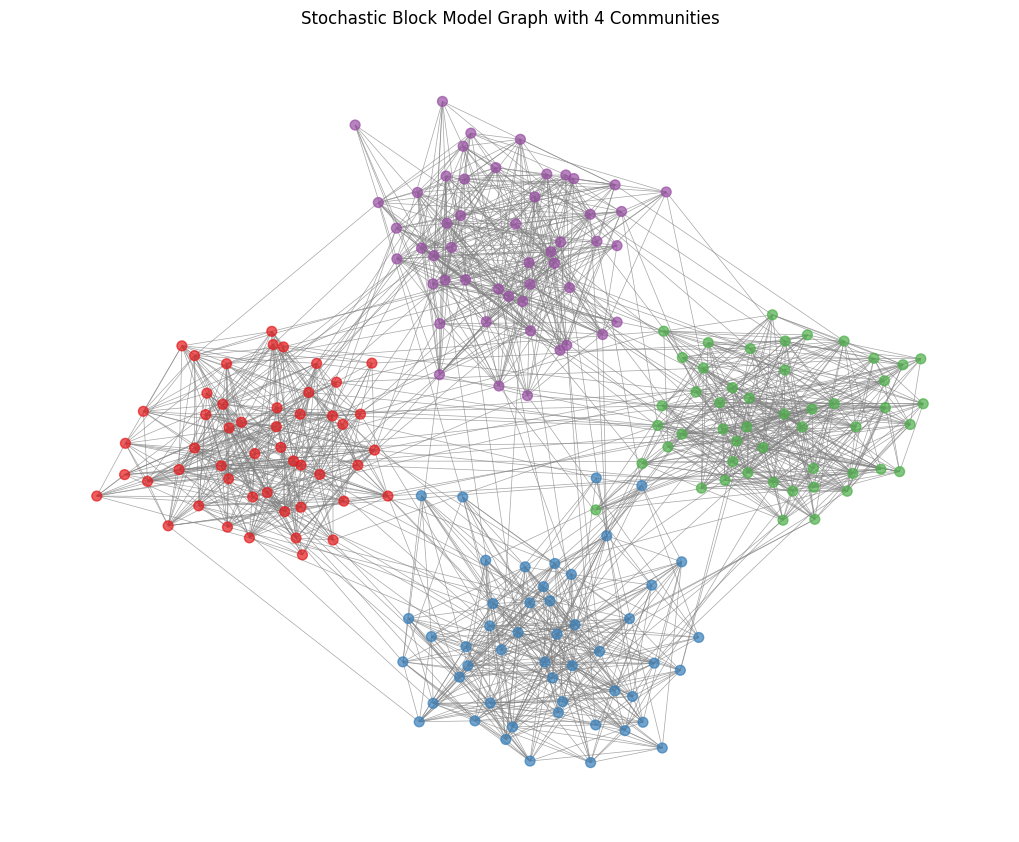

In [5]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Parameters for our synthetic graph
num_nodes = 200
num_classes = 4
nodes_per_class = num_nodes // num_classes
feature_dim = 16

# Create a stochastic block model graph
# This generates a graph with community structure
sizes = [nodes_per_class] * num_classes
# Probability matrix: higher probability within communities
p_intra = 0.3  # Probability of edge within same community
p_inter = 0.01  # Probability of edge between different communities
probs = np.full((num_classes, num_classes), p_inter)
np.fill_diagonal(probs, p_intra)

G = nx.stochastic_block_model(sizes, probs, seed = 42)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
# Get the ground truth community assignments
node_labels = np.array([i // nodes_per_class for i in range(num_nodes)])

# Create a color map for visualization
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
node_colors = [colors[label] for label in node_labels]

# Draw the graph
plt.figure(figsize = (10, 8))
pos = nx.spring_layout(G, seed = 42, k = 0.5)
nx.draw(G, pos, node_color = node_colors, node_size = 50, 
        edge_color = 'gray', alpha = 0.7, width = 0.5)
plt.title("Stochastic Block Model Graph with 4 Communities")
plt.tight_layout()
plt.savefig("./images/Practice0/sbm_graph.png", dpi = 400)
plt.show()

In [6]:
# Create class centers in the feature space
class_centers = np.random.randn(num_classes, feature_dim) * 2

# Assign features to nodes based on their class
# Each node gets the class center plus some Gaussian noise
node_features = np.zeros((num_nodes, feature_dim))
for i in range(num_nodes):
    label = node_labels[i]
    noise = np.random.randn(feature_dim) * 0.5
    node_features[i] = class_centers[label] + noise

print(f"Feature matrix shape: {node_features.shape}")
print(f"Feature statistics - Mean: {node_features.mean():.3f}, Std: {node_features.std():.3f}")

Feature matrix shape: (200, 16)
Feature statistics - Mean: -0.368, Std: 1.852


In [7]:
# Count labels per class
unique, counts = np.unique(node_labels, return_counts = True)
print("Label distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} nodes")

Label distribution:
  Class 0: 50 nodes
  Class 1: 50 nodes
  Class 2: 50 nodes
  Class 3: 50 nodes


In [8]:
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

# Convert features and labels to PyTorch tensors
x = torch.tensor(node_features, dtype = torch.float)
y = torch.tensor(node_labels, dtype = torch.long)

# Convert NetworkX graph to edge_index format
# PyG uses COO format: edge_index[0] contains source nodes, edge_index[1] contains target nodes
edge_list = list(G.edges())
edge_index = torch.tensor(edge_list, dtype = torch.long).t().contiguous()

# For undirected graphs, we need edges in both directions
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim = 1)

# Create the PyG Data object
data = Data(x = x, edge_index = edge_index, y = y)

print(data)
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of features per node: {data.num_node_features}")
print(f"Has isolated nodes: {data.has_isolated_nodes()}")
print(f"Has self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Data(x=[200, 16], edge_index=[2, 3216], y=[200])
Number of nodes: 200
Number of edges: 3216
Number of features per node: 16
Has isolated nodes: False
Has self-loops: False
Is undirected: True


In [9]:
def create_masks(num_nodes, num_classes, train_ratio = 0.6, val_ratio = 0.2, seed = 0):
    """
    Create train/val/test masks for node classification.
    
    Args:
        num_nodes: Total number of nodes
        num_classes: Number of classes
        train_ratio: Fraction of nodes for training
        val_ratio: Fraction of nodes for validation
        seed: Random seed for reproducibility
    
    Returns:
        train_mask, val_mask, test_mask as boolean tensors
    """
    np.random.seed(seed)
    
    indices = np.random.permutation(num_nodes)
    train_size = int(num_nodes * train_ratio)
    val_size = int(num_nodes * val_ratio)
    
    train_idx = indices[:train_size]
    val_idx = indices[train_size:train_size + val_size]
    test_idx = indices[train_size + val_size:]
    
    train_mask = torch.zeros(num_nodes, dtype = torch.bool)
    val_mask = torch.zeros(num_nodes, dtype = torch.bool)
    test_mask = torch.zeros(num_nodes, dtype = torch.bool)
    
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    
    return train_mask, val_mask, test_mask


# Create masks for 10 different runs
num_runs = 10
all_masks = []

for run in range(num_runs):
    train_mask, val_mask, test_mask = create_masks(
        data.num_nodes, num_classes, seed = run
    )
    all_masks.append({
        'train': train_mask,
        'val': val_mask,
        'test': test_mask
    })
    
# Verify the first split
print(f"Run 0 - Train nodes: {all_masks[0]['train'].sum().item()}")
print(f"Run 0 - Val nodes: {all_masks[0]['val'].sum().item()}")
print(f"Run 0 - Test nodes: {all_masks[0]['test'].sum().item()}")

Run 0 - Train nodes: 120
Run 0 - Val nodes: 40
Run 0 - Test nodes: 40


In [10]:
import torch
import torch.nn.functional as F

def simple_message_passing(x, edge_index, weight_matrix):
    """
    Perform one step of message passing.
    
    Args:
        x: Node features [num_nodes, in_features]
        edge_index: Graph connectivity [2, num_edges]
        weight_matrix: Learnable weights [in_features, out_features]
    
    Returns:
        Updated node features [num_nodes, out_features]
    """
    num_nodes = x.size(0)
    
    # Step 1: Transform features
    x_transformed = x @ weight_matrix  # [num_nodes, out_features]
    
    # Step 2: Aggregate neighbor features
    # Initialize output with zeros
    out = torch.zeros_like(x_transformed)
    
    # Get source and target nodes
    source_nodes = edge_index[0]  # Nodes sending messages
    target_nodes = edge_index[1]  # Nodes receiving messages
    
    # Aggregate: for each edge, add source node's features to target node
    # This is equivalent to multiplying by the adjacency matrix
    for i in range(edge_index.size(1)):
        src = source_nodes[i].item()
        tgt = target_nodes[i].item()
        out[tgt] += x_transformed[src]
    
    # Step 3: Normalize by node degree (mean aggregation)
    # Count incoming edges for each node
    degree = torch.zeros(num_nodes)
    for i in range(edge_index.size(1)):
        tgt = target_nodes[i].item()
        degree[tgt] += 1
    
    # Avoid division by zero
    degree = torch.clamp(degree, min = 1)
    
    # Normalize
    out = out / degree.unsqueeze(1)
    
    # Step 4: Apply non-linearity
    out = F.relu(out)
    
    return out


# Test our implementation
in_features = data.num_node_features
out_features = 8

# Initialize random weights
W = torch.randn(in_features, out_features) * 0.1

# Perform message passing
h1 = simple_message_passing(data.x, data.edge_index, W)
print(f"Input shape: {data.x.shape}")
print(f"Output shape: {h1.shape}")

Input shape: torch.Size([200, 16])
Output shape: torch.Size([200, 8])


In [11]:
from torch_geometric.utils import degree

def efficient_message_passing(x, edge_index, weight_matrix):
    """
    Efficient message passing using scatter operations.
    
    Args:
        x: Node features [num_nodes, in_features]
        edge_index: Graph connectivity [2, num_edges]
        weight_matrix: Learnable weights [in_features, out_features]
    
    Returns:
        Updated node features [num_nodes, out_features]
    """
    num_nodes = x.size(0)
    
    # Transform features
    x_transformed = x @ weight_matrix
    
    # Get source and target nodes
    source_nodes = edge_index[0]
    target_nodes = edge_index[1]
    
    # Gather source node features for each edge
    messages = x_transformed[source_nodes]  # [num_edges, out_features]
    
    # Scatter-add: aggregate messages to target nodes
    out = torch.zeros(num_nodes, x_transformed.size(1))
    out.scatter_add_(0, target_nodes.unsqueeze(1).expand_as(messages), messages)
    
    # Normalize by degree
    deg = degree(target_nodes, num_nodes = num_nodes)
    deg = torch.clamp(deg, min = 1)
    out = out / deg.unsqueeze(1)
    
    # Apply non-linearity
    out = F.relu(out)
    
    return out


# Verify both implementations give the same result
h1_slow = simple_message_passing(data.x, data.edge_index, W)
h1_fast = efficient_message_passing(data.x, data.edge_index, W)
print(f"Implementations match: {torch.allclose(h1_slow, h1_fast, atol = 1e-6)}")

Implementations match: True


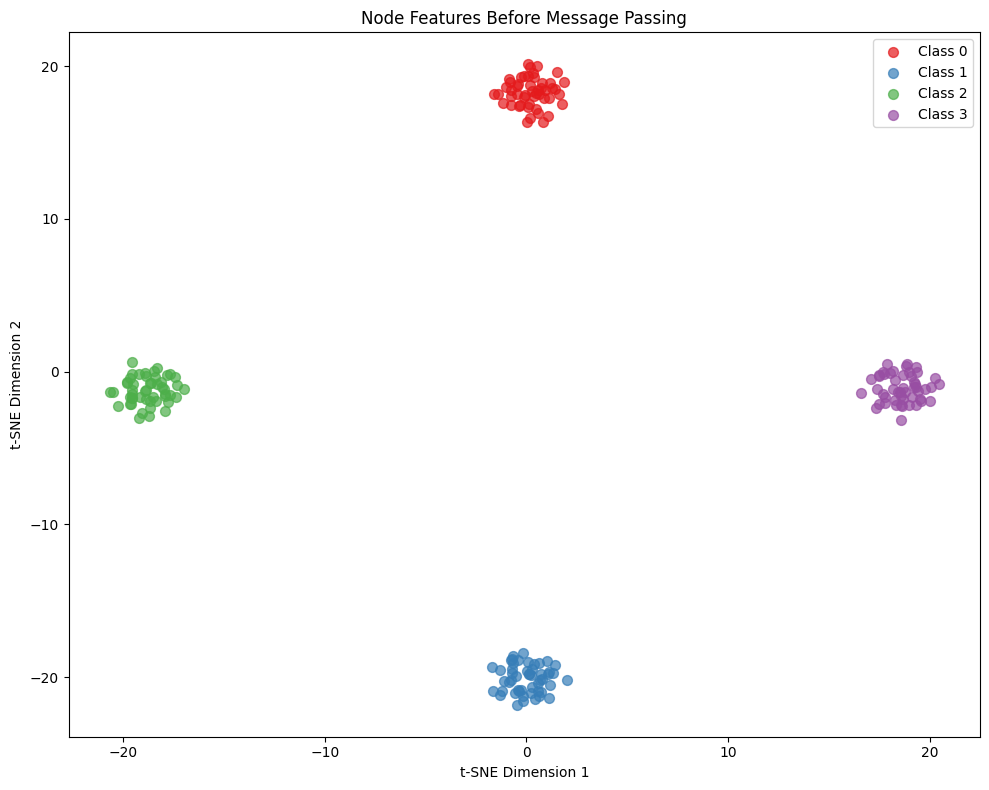

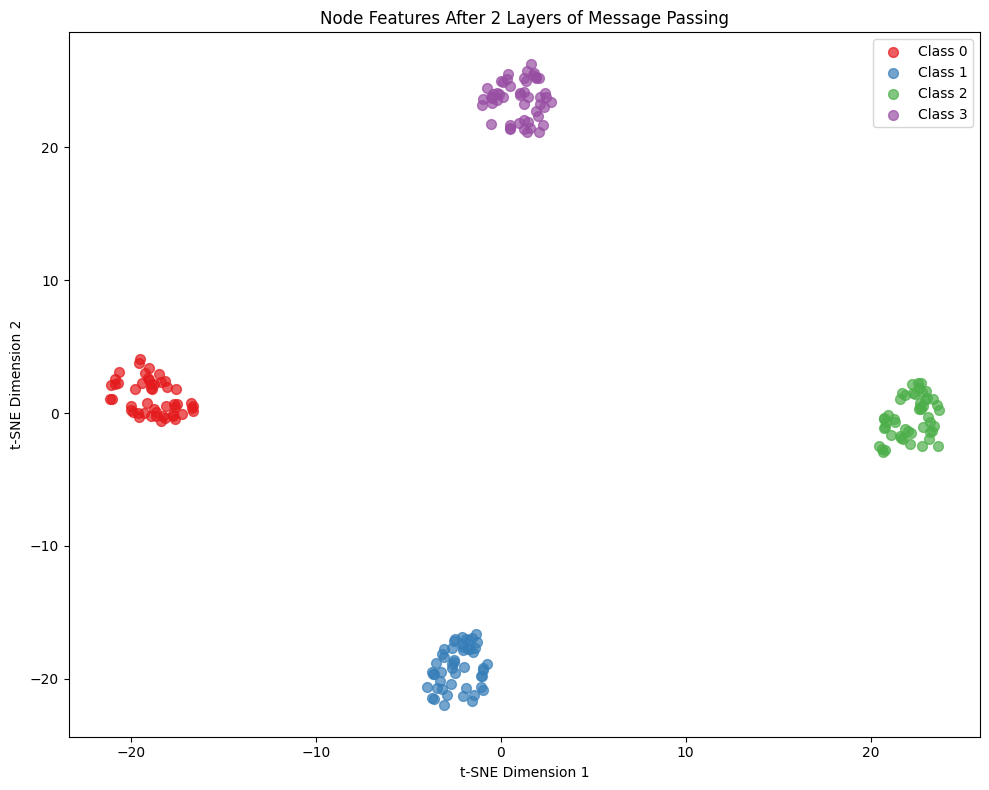

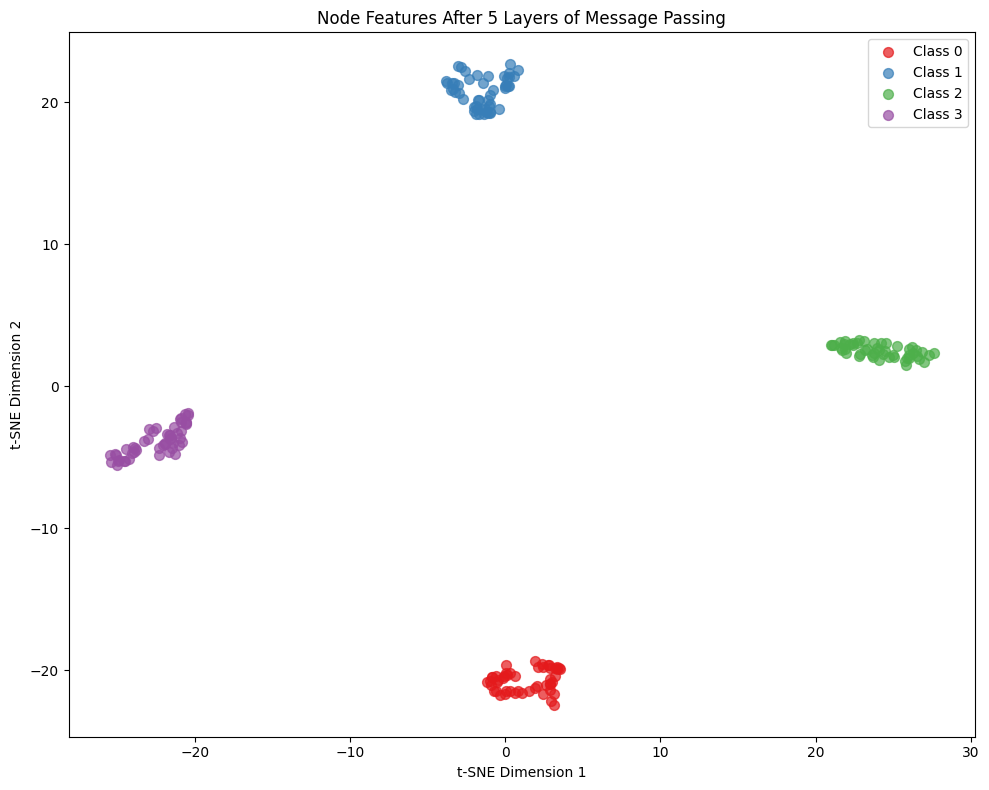

In [14]:
from sklearn.manifold import TSNE

def visualize_embeddings(embeddings, labels, title, filename):
    """
    Visualize node embeddings using t-SNE.
    
    Args:
        embeddings: Node embeddings [num_nodes, embedding_dim]
        labels: Node labels [num_nodes]
        title: Plot title
        filename: Output filename
    """
    # Apply t-SNE
    tsne = TSNE(n_components = 2, random_state = 42, perplexity = 30)
    embeddings_2d = tsne.fit_transform(embeddings.detach().numpy())
    
    # Plot
    plt.figure(figsize = (10, 8))
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
    
    for class_idx in range(num_classes):
        mask = labels == class_idx
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c = colors[class_idx],
            label = f'Class {class_idx}',
            alpha = 0.7,
            s = 50
        )
    
    plt.legend()
    plt.title(title)
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.tight_layout()
    plt.savefig(filename, dpi = 150)
    plt.show()


# Visualize original features
visualize_embeddings(
    data.x, 
    data.y.numpy(), 
    "Node Features Before Message Passing",
    "./images/Practice0/tsne_before_mp.png"
)

# Apply multiple rounds of message passing
W1 = torch.randn(feature_dim, 32) * 0.1
W2 = torch.randn(32, 16) * 0.1
W3 = torch.randn(16, 16) * 0.1
W4 = torch.randn(16, 16) * 0.1
W5 = torch.randn(16, 16) * 0.1

h1 = efficient_message_passing(data.x, data.edge_index, W1)
h2 = efficient_message_passing(h1, data.edge_index, W2)
h3 = efficient_message_passing(h2, data.edge_index, W3)
h4 = efficient_message_passing(h3, data.edge_index, W4)
h5 = efficient_message_passing(h4, data.edge_index, W5)

# Visualize after message passing
visualize_embeddings(
    h2,
    data.y.numpy(),
    "Node Features After 2 Layers of Message Passing",
    "./images/Practice0/tsne_after_mp.png"
)
# Visualize after 5 layers of message passing
visualize_embeddings(
    h5,
    data.y.numpy(),
    "Node Features After 5 Layers of Message Passing",
    "./images/Practice0/tsne_after_5mp.png"
)

In [15]:
import torch.nn as nn

class MLP(nn.Module):
    """
    Simple Multi-Layer Perceptron for node classification.
    This baseline ignores the graph structure.
    """
    
    def __init__(self, in_channels, hidden_channels, out_channels, dropout = 0.5):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(in_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # First layer
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        # Second layer (output)
        x = self.fc2(x)
        return x


# Create MLP model
mlp_model = MLP(
    in_channels = data.num_node_features,
    hidden_channels = 64,
    out_channels = num_classes
)
print(mlp_model)

MLP(
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=4, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [16]:
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    """
    Graph Convolutional Network for node classification.
    """
    
    def __init__(self, in_channels, hidden_channels, out_channels, dropout = 0.5):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, edge_index):
        # First GCN layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        # Second GCN layer
        x = self.conv2(x, edge_index)
        return x


# Create GCN model
gcn_model = GCN(
    in_channels = data.num_node_features,
    hidden_channels = 64,
    out_channels = num_classes
)
print(gcn_model)

GCN(
  (conv1): GCNConv(16, 64)
  (conv2): GCNConv(64, 4)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [17]:
def train_epoch(model, data, optimizer, criterion, train_mask):
    """
    Train the model for one epoch.
    
    Args:
        model: The neural network model
        data: PyG Data object
        optimizer: PyTorch optimizer
        criterion: Loss function
        train_mask: Boolean mask for training nodes
    
    Returns:
        Training loss
    """
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    if isinstance(model, MLP):
        out = model(data.x)
    else:
        out = model(data.x, data.edge_index)
    
    # Compute loss only on training nodes
    loss = criterion(out[train_mask], data.y[train_mask])
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    """
    Evaluate the model on a set of nodes.
    
    Args:
        model: The neural network model
        data: PyG Data object
        mask: Boolean mask for evaluation nodes
    
    Returns:
        Accuracy on the specified nodes
    """
    model.eval()
    
    # Forward pass
    if isinstance(model, MLP):
        out = model(data.x)
    else:
        out = model(data.x, data.edge_index)
    
    # Get predictions
    pred = out.argmax(dim = 1)
    
    # Compute accuracy
    correct = (pred[mask] == data.y[mask]).sum().item()
    total = mask.sum().item()
    
    return correct / total

In [18]:
def run_experiment(model, data, masks, num_epochs = 200, lr = 0.01, weight_decay = 5e-4):
    """
    Run a complete training experiment.
    
    Args:
        model: The neural network model
        data: PyG Data object
        masks: Dictionary with train/val/test masks
        num_epochs: Number of training epochs
        lr: Learning rate
        weight_decay: L2 regularization strength
    
    Returns:
        Dictionary with training history and final metrics
    """
    optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay)
    criterion = nn.CrossEntropyLoss()
    
    train_mask = masks['train']
    val_mask = masks['val']
    test_mask = masks['test']
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': [],
        'test_acc': []
    }
    
    best_val_acc = 0
    best_test_acc = 0
    
    for epoch in range(num_epochs):
        # Training
        loss = train_epoch(model, data, optimizer, criterion, train_mask)
        
        # Evaluation
        train_acc = evaluate(model, data, train_mask)
        val_acc = evaluate(model, data, val_mask)
        test_acc = evaluate(model, data, test_mask)
        
        # Store history
        history['train_loss'].append(loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['test_acc'].append(test_acc)
        
        # Track best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc
        
        # Print progress every 50 epochs
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch + 1:3d} | Loss: {loss:.4f} | "
                  f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")
    
    return {
        'history': history,
        'best_val_acc': best_val_acc,
        'best_test_acc': best_test_acc
    }

In [19]:
# Hyperparameters
num_epochs = 200
hidden_channels = 64
lr = 0.01
weight_decay = 5e-4

# Store results for all runs
mlp_results = []
gcn_results = []

for run in range(num_runs):
    print(f"\n{'=' * 50}")
    print(f"Run {run + 1}/{num_runs}")
    print('=' * 50)
    
    # Create new models for each run
    mlp = MLP(data.num_node_features, hidden_channels, num_classes)
    gcn = GCN(data.num_node_features, hidden_channels, num_classes)
    
    # Get masks for this run
    masks = all_masks[run]
    
    # Train MLP
    print("\nTraining MLP:")
    mlp_result = run_experiment(mlp, data, masks, num_epochs, lr, weight_decay)
    mlp_results.append(mlp_result)
    
    # Train GCN
    print("\nTraining GCN:")
    gcn_result = run_experiment(gcn, data, masks, num_epochs, lr, weight_decay)
    gcn_results.append(gcn_result)

# Compute statistics
mlp_test_accs = [r['best_test_acc'] for r in mlp_results]
gcn_test_accs = [r['best_test_acc'] for r in gcn_results]

print(f"\n{'=' * 50}")
print("Final Results (Test Accuracy)")
print('=' * 50)
print(f"MLP: {np.mean(mlp_test_accs):.4f} +/- {np.std(mlp_test_accs):.4f}")
print(f"GCN: {np.mean(gcn_test_accs):.4f} +/- {np.std(gcn_test_accs):.4f}")


Run 1/10

Training MLP:
Epoch  50 | Loss: 0.0058 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 100 | Loss: 0.0009 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 150 | Loss: 0.0004 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 200 | Loss: 0.0003 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000

Training GCN:
Epoch  50 | Loss: 0.0004 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 100 | Loss: 0.0002 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 150 | Loss: 0.0003 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 200 | Loss: 0.0003 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000

Run 2/10

Training MLP:
Epoch  50 | Loss: 0.0042 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 100 | Loss: 0.0128 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 150 | Loss: 0.0023 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 200 | Loss: 0.0002 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000

Training GCN:
Epoch  50 | Loss: 0.0001 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 100 

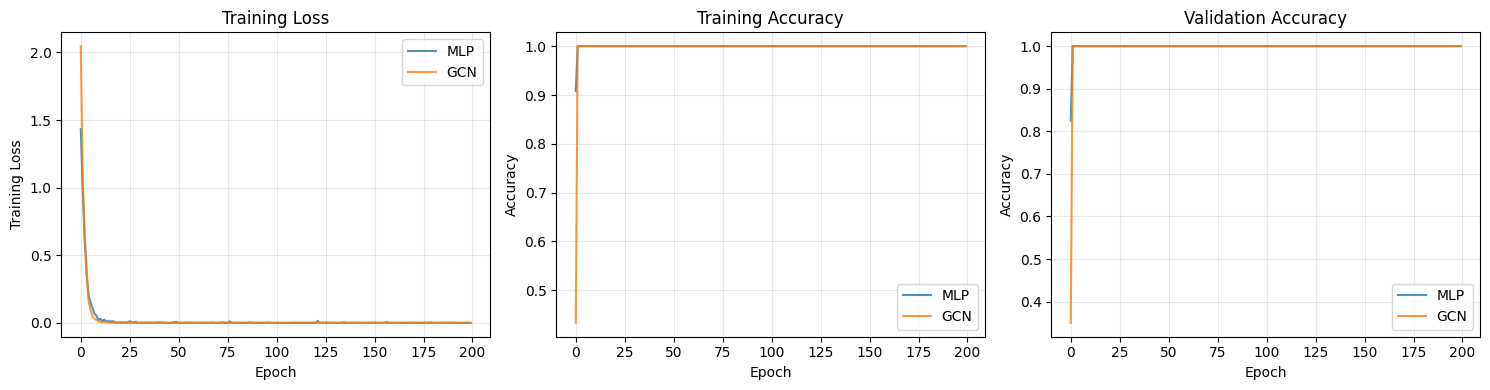

In [20]:
def plot_training_curves(mlp_history, gcn_history, filename):
    """
    Plot training curves for MLP and GCN.
    """
    fig, axes = plt.subplots(1, 3, figsize = (15, 4))
    
    # Loss curve
    axes[0].plot(mlp_history['train_loss'], label = 'MLP', alpha = 0.8)
    axes[0].plot(gcn_history['train_loss'], label = 'GCN', alpha = 0.8)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Training Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha = 0.3)
    
    # Training accuracy
    axes[1].plot(mlp_history['train_acc'], label = 'MLP', alpha = 0.8)
    axes[1].plot(gcn_history['train_acc'], label = 'GCN', alpha = 0.8)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha = 0.3)
    
    # Validation accuracy
    axes[2].plot(mlp_history['val_acc'], label = 'MLP', alpha = 0.8)
    axes[2].plot(gcn_history['val_acc'], label = 'GCN', alpha = 0.8)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy')
    axes[2].set_title('Validation Accuracy')
    axes[2].legend()
    axes[2].grid(True, alpha = 0.3)
    
    plt.tight_layout()
    plt.savefig(filename, dpi = 150)
    plt.show()


# Plot for the first run
plot_training_curves(
    mlp_results[0]['history'],
    gcn_results[0]['history'],
    "./images/Practice0/training_curves.png"
)


Epoch  50 | Loss: 0.0003 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 100 | Loss: 0.0017 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 150 | Loss: 0.0025 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 200 | Loss: 0.0003 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch  50 | Loss: 0.0002 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 100 | Loss: 0.0003 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 150 | Loss: 0.0003 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 200 | Loss: 0.0003 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000


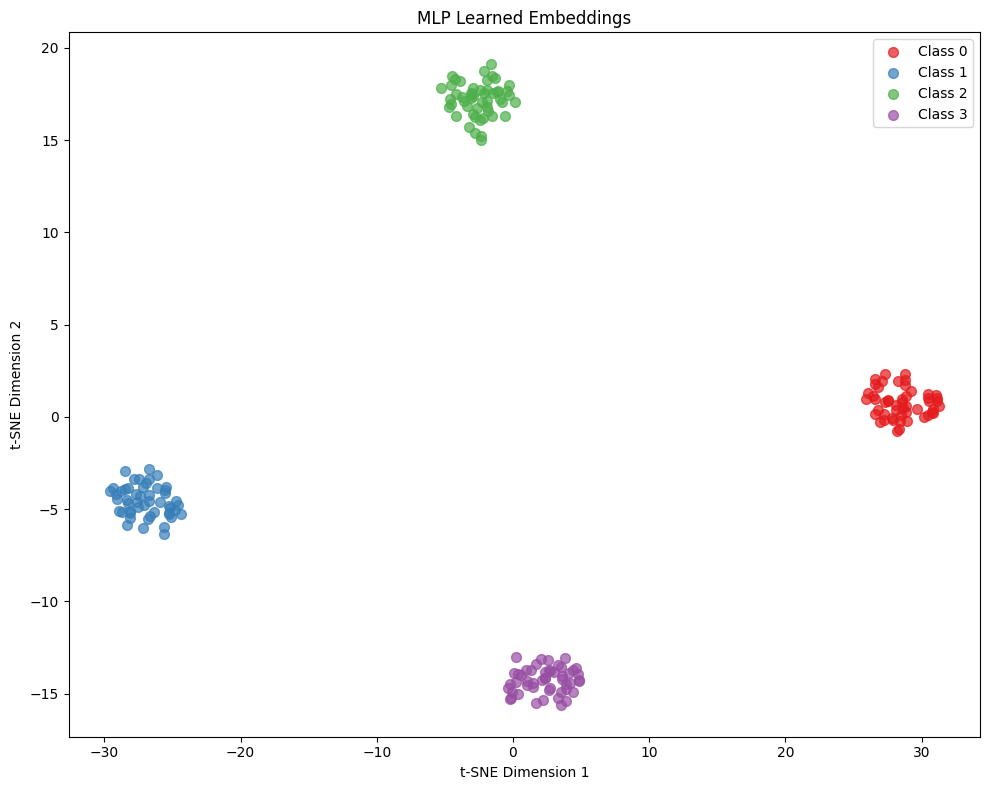

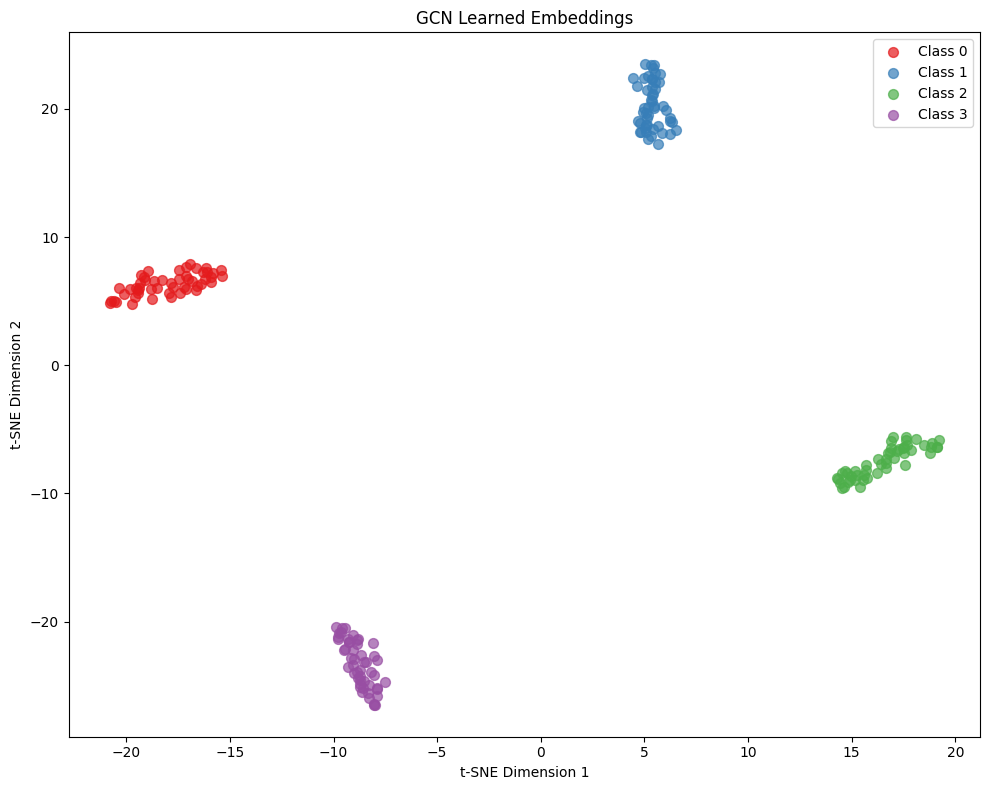

In [21]:
@torch.no_grad()
def get_embeddings(model, data):
    """
    Extract node embeddings from the model (before the final layer).
    """
    model.eval()
    
    if isinstance(model, GCN):
        x = model.conv1(data.x, data.edge_index)
        x = F.relu(x)
        return x
    else:
        x = model.fc1(data.x)
        x = F.relu(x)
        return x


# Get embeddings from trained models
mlp = MLP(data.num_node_features, hidden_channels, num_classes)
gcn = GCN(data.num_node_features, hidden_channels, num_classes)

# Train models (using first run masks)
masks = all_masks[0]
_ = run_experiment(mlp, data, masks, num_epochs, lr, weight_decay)
_ = run_experiment(gcn, data, masks, num_epochs, lr, weight_decay)

# Get and visualize embeddings
mlp_emb = get_embeddings(mlp, data)
gcn_emb = get_embeddings(gcn, data)

visualize_embeddings(
    mlp_emb,
    data.y.numpy(),
    "MLP Learned Embeddings",
    "./images/Practice0/mlp_embeddings.png"
)

visualize_embeddings(
    gcn_emb,
    data.y.numpy(),
    "GCN Learned Embeddings",
    "./images/Practice0/gcn_embeddings.png"
)

In [22]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Parameters for our synthetic graph
num_nodes = 200
num_classes = 4
nodes_per_class = num_nodes // num_classes
feature_dim = 16

# Create a stochastic block model graph
# This generates a graph with community structure
sizes = [nodes_per_class] * num_classes
# Probability matrix: higher probability within communities
p_intra = 0.3  # Probability of edge within same community
p_inter = 0.01  # Probability of edge between different communities
probs = np.full((num_classes, num_classes), p_inter)
np.fill_diagonal(probs, p_intra)

G = nx.stochastic_block_model(sizes, probs, seed = 42)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 200
Number of edges: 1608


/var/folders/mz/h7lyhbx179g0m6677zcjjdbc0000gn/T/ipykernel_54185/1084888389.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


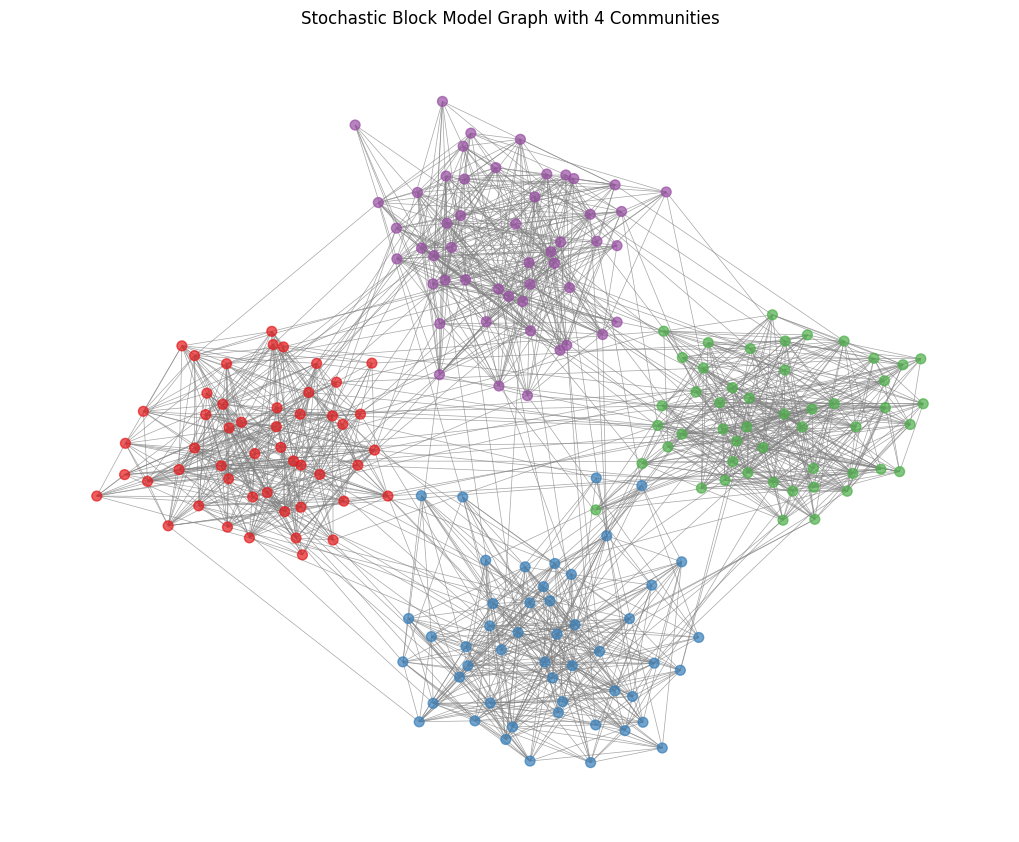

In [41]:
# Get the ground truth community assignments
node_labels = np.array([i // nodes_per_class for i in range(num_nodes)])

# Create a color map for visualization
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
node_colors = [colors[label] for label in node_labels]

# Draw the graph
plt.figure(figsize = (10, 8))
pos = nx.spring_layout(G, seed = 42, k = 0.5)
nx.draw(G, pos, node_color = node_colors, node_size = 50, 
        edge_color = 'gray', alpha = 0.7, width = 0.5)
plt.title("Stochastic Block Model Graph with 4 Communities")
plt.tight_layout()
plt.savefig("./images/Practice0/sbm_graph.png", dpi = 400)
plt.show()

In [42]:
# Create class centers in the feature space with SMALL magnitude
# The key difference: small class centers and large noise
class_centers = np.random.randn(num_classes, feature_dim) * 0.3

# Assign features to nodes based on their class
# Each node gets a WEAK class signal drowned in LARGE noise
node_features = np.zeros((num_nodes, feature_dim))
for i in range(num_nodes):
    label = node_labels[i]
    # Large noise dominates the weak class signal
    noise = np.random.randn(feature_dim) * 1.0            # Large noise
    weak_signal = class_centers[label] * 0.2              # Weak signal
    node_features[i] = weak_signal + noise

print(f"Feature matrix shape: {node_features.shape}")
print(f"Feature statistics - Mean: {node_features.mean():.3f}, Std: {node_features.std():.3f}")
print(f" Signal-to-Noise Ratio is LOW: MLP will struggle with classification!")

Feature matrix shape: (200, 16)
Feature statistics - Mean: -0.020, Std: 0.986
 Signal-to-Noise Ratio is LOW: MLP will struggle with classification!


In [43]:
# Count labels per class
unique, counts = np.unique(node_labels, return_counts = True)
print("Label distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} nodes")

Label distribution:
  Class 0: 50 nodes
  Class 1: 50 nodes
  Class 2: 50 nodes
  Class 3: 50 nodes


In [44]:
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

# Convert features and labels to PyTorch tensors
x = torch.tensor(node_features, dtype = torch.float)
y = torch.tensor(node_labels, dtype = torch.long)

# Convert NetworkX graph to edge_index format
# PyG uses COO format: edge_index[0] contains source nodes, edge_index[1] contains target nodes
edge_list = list(G.edges())
edge_index = torch.tensor(edge_list, dtype = torch.long).t().contiguous()

# For undirected graphs, we need edges in both directions
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim = 1)

# Create the PyG Data object
data = Data(x = x, edge_index = edge_index, y = y)

print(data)
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of features per node: {data.num_node_features}")
print(f"Has isolated nodes: {data.has_isolated_nodes()}")
print(f"Has self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Data(x=[200, 16], edge_index=[2, 3216], y=[200])
Number of nodes: 200
Number of edges: 3216
Number of features per node: 16
Has isolated nodes: False
Has self-loops: False
Is undirected: True


In [45]:
def create_masks(num_nodes, num_classes, train_ratio = 0.6, val_ratio = 0.2, seed = 0):
    """
    Create train/val/test masks for node classification.
    
    Args:
        num_nodes: Total number of nodes
        num_classes: Number of classes
        train_ratio: Fraction of nodes for training
        val_ratio: Fraction of nodes for validation
        seed: Random seed for reproducibility
    
    Returns:
        train_mask, val_mask, test_mask as boolean tensors
    """
    np.random.seed(seed)
    
    indices = np.random.permutation(num_nodes)
    train_size = int(num_nodes * train_ratio)
    val_size = int(num_nodes * val_ratio)
    
    train_idx = indices[:train_size]
    val_idx = indices[train_size:train_size + val_size]
    test_idx = indices[train_size + val_size:]
    
    train_mask = torch.zeros(num_nodes, dtype = torch.bool)
    val_mask = torch.zeros(num_nodes, dtype = torch.bool)
    test_mask = torch.zeros(num_nodes, dtype = torch.bool)
    
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    
    return train_mask, val_mask, test_mask


# Create masks for 10 different runs
num_runs = 10
all_masks = []

for run in range(num_runs):
    train_mask, val_mask, test_mask = create_masks(
        data.num_nodes, num_classes, seed = run
    )
    all_masks.append({
        'train': train_mask,
        'val': val_mask,
        'test': test_mask
    })
    
# Verify the first split
print(f"Run 0 - Train nodes: {all_masks[0]['train'].sum().item()}")
print(f"Run 0 - Val nodes: {all_masks[0]['val'].sum().item()}")
print(f"Run 0 - Test nodes: {all_masks[0]['test'].sum().item()}")

Run 0 - Train nodes: 120
Run 0 - Val nodes: 40
Run 0 - Test nodes: 40


In [46]:
import torch
import torch.nn.functional as F

def simple_message_passing(x, edge_index, weight_matrix):
    """
    Perform one step of message passing.
    
    Args:
        x: Node features [num_nodes, in_features]
        edge_index: Graph connectivity [2, num_edges]
        weight_matrix: Learnable weights [in_features, out_features]
    
    Returns:
        Updated node features [num_nodes, out_features]
    """
    num_nodes = x.size(0)
    
    # Step 1: Transform features
    x_transformed = x @ weight_matrix  # [num_nodes, out_features]
    
    # Step 2: Aggregate neighbor features
    # Initialize output with zeros
    out = torch.zeros_like(x_transformed)
    
    # Get source and target nodes
    source_nodes = edge_index[0]  # Nodes sending messages
    target_nodes = edge_index[1]  # Nodes receiving messages
    
    # Aggregate: for each edge, add source node's features to target node
    # This is equivalent to multiplying by the adjacency matrix
    for i in range(edge_index.size(1)):
        src = source_nodes[i].item()
        tgt = target_nodes[i].item()
        out[tgt] += x_transformed[src]
    
    # Step 3: Normalize by node degree (mean aggregation)
    # Count incoming edges for each node
    degree = torch.zeros(num_nodes)
    for i in range(edge_index.size(1)):
        tgt = target_nodes[i].item()
        degree[tgt] += 1
    
    # Avoid division by zero
    degree = torch.clamp(degree, min = 1)
    
    # Normalize
    out = out / degree.unsqueeze(1)
    
    # Step 4: Apply non-linearity
    out = F.relu(out)
    
    return out


# Test our implementation
in_features = data.num_node_features
out_features = 8

# Initialize random weights
W = torch.randn(in_features, out_features) * 0.1

# Perform message passing
h1 = simple_message_passing(data.x, data.edge_index, W)
print(f"Input shape: {data.x.shape}")
print(f"Output shape: {h1.shape}")

Input shape: torch.Size([200, 16])
Output shape: torch.Size([200, 8])


In [47]:
from torch_geometric.utils import degree

def efficient_message_passing(x, edge_index, weight_matrix):
    """
    Efficient message passing using scatter operations.
    
    Args:
        x: Node features [num_nodes, in_features]
        edge_index: Graph connectivity [2, num_edges]
        weight_matrix: Learnable weights [in_features, out_features]
    
    Returns:
        Updated node features [num_nodes, out_features]
    """
    num_nodes = x.size(0)
    
    # Transform features
    x_transformed = x @ weight_matrix
    
    # Get source and target nodes
    source_nodes = edge_index[0]
    target_nodes = edge_index[1]
    
    # Gather source node features for each edge
    messages = x_transformed[source_nodes]  # [num_edges, out_features]
    
    # Scatter-add: aggregate messages to target nodes
    out = torch.zeros(num_nodes, x_transformed.size(1))
    out.scatter_add_(0, target_nodes.unsqueeze(1).expand_as(messages), messages)
    
    # Normalize by degree
    deg = degree(target_nodes, num_nodes = num_nodes)
    deg = torch.clamp(deg, min = 1)
    out = out / deg.unsqueeze(1)
    
    # Apply non-linearity
    out = F.relu(out)
    
    return out


# Verify both implementations give the same result
h1_slow = simple_message_passing(data.x, data.edge_index, W)
h1_fast = efficient_message_passing(data.x, data.edge_index, W)
print(f"Implementations match: {torch.allclose(h1_slow, h1_fast, atol = 1e-6)}")

Implementations match: True


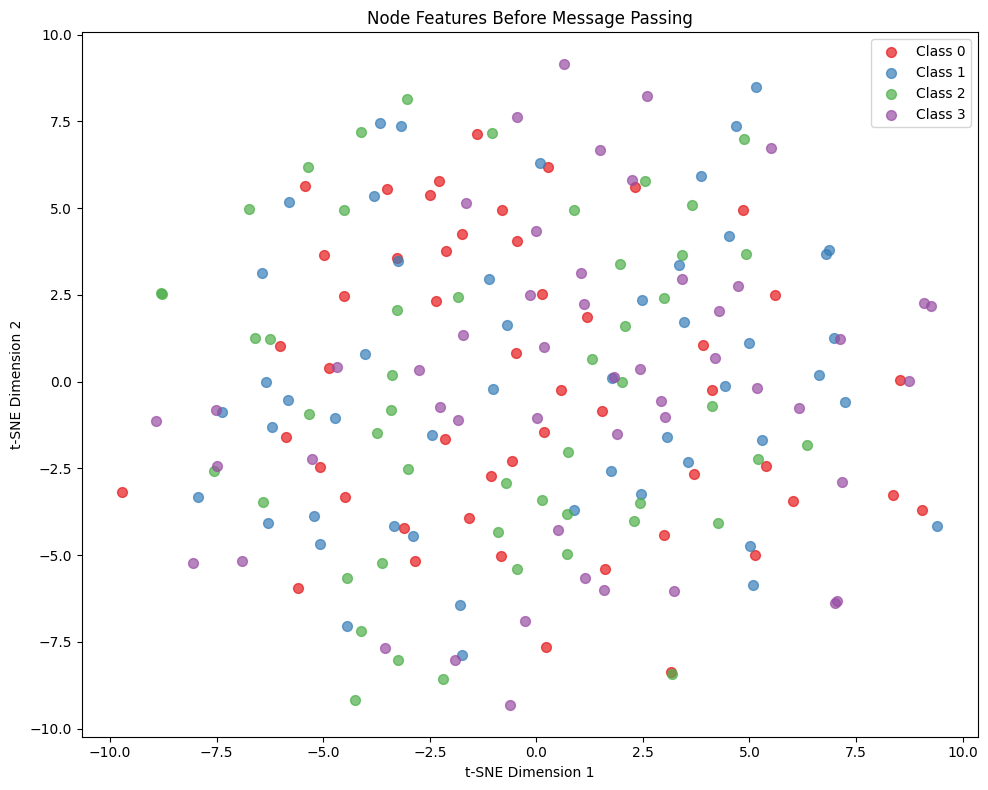

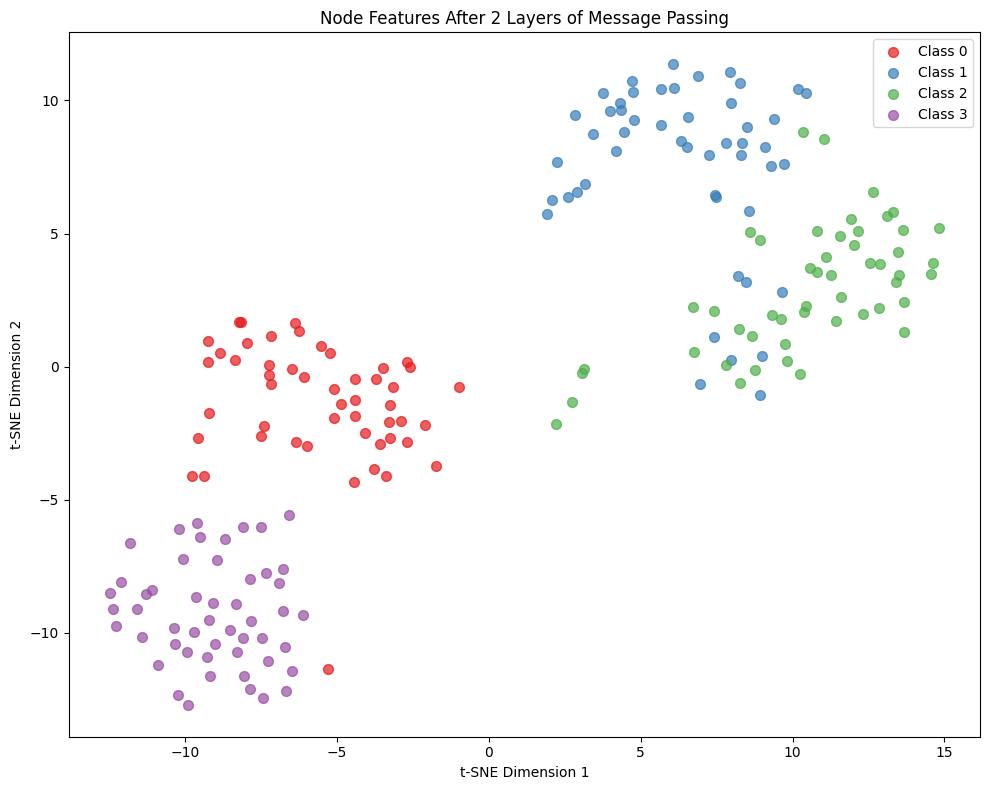

In [48]:
from sklearn.manifold import TSNE

def visualize_embeddings(embeddings, labels, title, filename):
    """
    Visualize node embeddings using t-SNE.
    
    Args:
        embeddings: Node embeddings [num_nodes, embedding_dim]
        labels: Node labels [num_nodes]
        title: Plot title
        filename: Output filename
    """
    # Apply t-SNE
    tsne = TSNE(n_components = 2, random_state = 42, perplexity = 30)
    embeddings_2d = tsne.fit_transform(embeddings.detach().numpy())
    
    # Plot
    plt.figure(figsize = (10, 8))
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
    
    for class_idx in range(num_classes):
        mask = labels == class_idx
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c = colors[class_idx],
            label = f'Class {class_idx}',
            alpha = 0.7,
            s = 50
        )
    
    plt.legend()
    plt.title(title)
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.tight_layout()
    plt.savefig(filename, dpi = 150)
    plt.show()


# Visualize original features
visualize_embeddings(
    data.x, 
    data.y.numpy(), 
    "Node Features Before Message Passing",
    "./images/Practice0/tsne_before_mp.png"
)

# Apply multiple rounds of message passing
W1 = torch.randn(feature_dim, 32) * 0.1
W2 = torch.randn(32, 16) * 0.1

h1 = efficient_message_passing(data.x, data.edge_index, W1)
h2 = efficient_message_passing(h1, data.edge_index, W2)

# Visualize after message passing
visualize_embeddings(
    h2,
    data.y.numpy(),
    "Node Features After 2 Layers of Message Passing",
    "./images/Practice0/tsne_after_mp.png"
)


In [49]:
import torch.nn as nn

class MLP(nn.Module):
    """
    Simple Multi-Layer Perceptron for node classification.
    This baseline ignores the graph structure.
    """
    
    def __init__(self, in_channels, hidden_channels, out_channels, dropout = 0.5):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(in_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # First layer
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        # Second layer (output)
        x = self.fc2(x)
        return x


# Create MLP model
mlp_model = MLP(
    in_channels = data.num_node_features,
    hidden_channels = 64,
    out_channels = num_classes
)
print(mlp_model)

MLP(
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=4, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [50]:
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    """
    Graph Convolutional Network for node classification.
    """
    
    def __init__(self, in_channels, hidden_channels, out_channels, dropout = 0.5):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, edge_index):
        # First GCN layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        # Second GCN layer
        x = self.conv2(x, edge_index)
        return x


# Create GCN model
gcn_model = GCN(
    in_channels = data.num_node_features,
    hidden_channels = 64,
    out_channels = num_classes
)
print(gcn_model)

GCN(
  (conv1): GCNConv(16, 64)
  (conv2): GCNConv(64, 4)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [51]:
def train_epoch(model, data, optimizer, criterion, train_mask):
    """
    Train the model for one epoch.
    
    Args:
        model: The neural network model
        data: PyG Data object
        optimizer: PyTorch optimizer
        criterion: Loss function
        train_mask: Boolean mask for training nodes
    
    Returns:
        Training loss
    """
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    if isinstance(model, MLP):
        out = model(data.x)
    else:
        out = model(data.x, data.edge_index)
    
    # Compute loss only on training nodes
    loss = criterion(out[train_mask], data.y[train_mask])
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    """
    Evaluate the model on a set of nodes.
    
    Args:
        model: The neural network model
        data: PyG Data object
        mask: Boolean mask for evaluation nodes
    
    Returns:
        Accuracy on the specified nodes
    """
    model.eval()
    
    # Forward pass
    if isinstance(model, MLP):
        out = model(data.x)
    else:
        out = model(data.x, data.edge_index)
    
    # Get predictions
    pred = out.argmax(dim = 1)
    
    # Compute accuracy
    correct = (pred[mask] == data.y[mask]).sum().item()
    total = mask.sum().item()
    
    return correct / total

In [52]:
def run_experiment(model, data, masks, num_epochs = 200, lr = 0.01, weight_decay = 5e-4):
    """
    Run a complete training experiment.
    
    Args:
        model: The neural network model
        data: PyG Data object
        masks: Dictionary with train/val/test masks
        num_epochs: Number of training epochs
        lr: Learning rate
        weight_decay: L2 regularization strength
    
    Returns:
        Dictionary with training history and final metrics
    """
    optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay)
    criterion = nn.CrossEntropyLoss()
    
    train_mask = masks['train']
    val_mask = masks['val']
    test_mask = masks['test']
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': [],
        'test_acc': []
    }
    
    best_val_acc = 0
    best_test_acc = 0
    
    for epoch in range(num_epochs):
        # Training
        loss = train_epoch(model, data, optimizer, criterion, train_mask)
        
        # Evaluation
        train_acc = evaluate(model, data, train_mask)
        val_acc = evaluate(model, data, val_mask)
        test_acc = evaluate(model, data, test_mask)
        
        # Store history
        history['train_loss'].append(loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['test_acc'].append(test_acc)
        
        # Track best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc
        
        # Print progress every 50 epochs
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch + 1:3d} | Loss: {loss:.4f} | "
                  f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")
    
    return {
        'history': history,
        'best_val_acc': best_val_acc,
        'best_test_acc': best_test_acc
    }

In [53]:

# Hyperparameters
num_epochs = 200
hidden_channels = 64
lr = 0.01
weight_decay = 5e-4

# Store results for all runs
mlp_results = []
gcn_results = []

for run in range(num_runs):
    print(f"\n{'=' * 50}")
    print(f"Run {run + 1}/{num_runs}")
    print('=' * 50)
    
    # Create new models for each run
    mlp = MLP(data.num_node_features, hidden_channels, num_classes)
    gcn = GCN(data.num_node_features, hidden_channels, num_classes)
    
    # Get masks for this run
    masks = all_masks[run]
    
    # Train MLP
    print("\nTraining MLP:")
    mlp_result = run_experiment(mlp, data, masks, num_epochs, lr, weight_decay)
    mlp_results.append(mlp_result)
    
    # Train GCN
    print("\nTraining GCN:")
    gcn_result = run_experiment(gcn, data, masks, num_epochs, lr, weight_decay)
    gcn_results.append(gcn_result)

# Compute statistics
mlp_test_accs = [r['best_test_acc'] for r in mlp_results]
gcn_test_accs = [r['best_test_acc'] for r in gcn_results]

print(f"\n{'=' * 50}")
print("Final Results (Test Accuracy)")
print('=' * 50)
print(f"MLP: {np.mean(mlp_test_accs):.4f} +/- {np.std(mlp_test_accs):.4f}")
print(f"GCN: {np.mean(gcn_test_accs):.4f} +/- {np.std(gcn_test_accs):.4f}")


Run 1/10

Training MLP:
Epoch  50 | Loss: 0.6800 | Train: 0.9083 | Val: 0.3250 | Test: 0.1500
Epoch 100 | Loss: 0.3729 | Train: 1.0000 | Val: 0.3250 | Test: 0.1750
Epoch 150 | Loss: 0.3034 | Train: 1.0000 | Val: 0.3000 | Test: 0.1750
Epoch 200 | Loss: 0.2488 | Train: 1.0000 | Val: 0.3500 | Test: 0.2000

Training GCN:
Epoch  50 | Loss: 0.0205 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 100 | Loss: 0.0110 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 150 | Loss: 0.0093 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 200 | Loss: 0.0091 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000

Run 2/10

Training MLP:
Epoch  50 | Loss: 0.5989 | Train: 0.8917 | Val: 0.2750 | Test: 0.1500
Epoch 100 | Loss: 0.2996 | Train: 1.0000 | Val: 0.2750 | Test: 0.1750
Epoch 150 | Loss: 0.2281 | Train: 1.0000 | Val: 0.2500 | Test: 0.1750
Epoch 200 | Loss: 0.1758 | Train: 1.0000 | Val: 0.2500 | Test: 0.1750

Training GCN:
Epoch  50 | Loss: 0.0252 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 100 

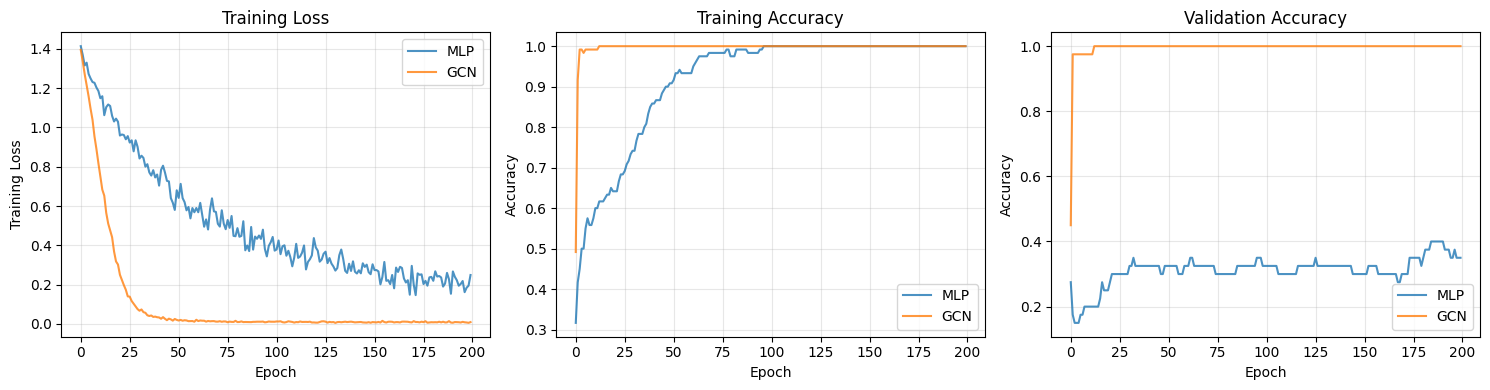

In [54]:
def plot_training_curves(mlp_history, gcn_history, filename):
    """
    Plot training curves for MLP and GCN.
    """
    fig, axes = plt.subplots(1, 3, figsize = (15, 4))
    
    # Loss curve
    axes[0].plot(mlp_history['train_loss'], label = 'MLP', alpha = 0.8)
    axes[0].plot(gcn_history['train_loss'], label = 'GCN', alpha = 0.8)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Training Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha = 0.3)
    
    # Training accuracy
    axes[1].plot(mlp_history['train_acc'], label = 'MLP', alpha = 0.8)
    axes[1].plot(gcn_history['train_acc'], label = 'GCN', alpha = 0.8)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha = 0.3)
    
    # Validation accuracy
    axes[2].plot(mlp_history['val_acc'], label = 'MLP', alpha = 0.8)
    axes[2].plot(gcn_history['val_acc'], label = 'GCN', alpha = 0.8)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy')
    axes[2].set_title('Validation Accuracy')
    axes[2].legend()
    axes[2].grid(True, alpha = 0.3)
    
    plt.tight_layout()
    plt.savefig(filename, dpi = 150)
    plt.show()


# Plot for the first run
plot_training_curves(
    mlp_results[0]['history'],
    gcn_results[0]['history'],
    "./images/Practice0/training_curves.png"
)

Epoch  50 | Loss: 0.6318 | Train: 0.9417 | Val: 0.3000 | Test: 0.2250
Epoch 100 | Loss: 0.3996 | Train: 1.0000 | Val: 0.3500 | Test: 0.2750
Epoch 150 | Loss: 0.3326 | Train: 1.0000 | Val: 0.3250 | Test: 0.2750
Epoch 200 | Loss: 0.2016 | Train: 1.0000 | Val: 0.3500 | Test: 0.2250
Epoch  50 | Loss: 0.0195 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 100 | Loss: 0.0120 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 150 | Loss: 0.0082 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000
Epoch 200 | Loss: 0.0089 | Train: 1.0000 | Val: 1.0000 | Test: 1.0000


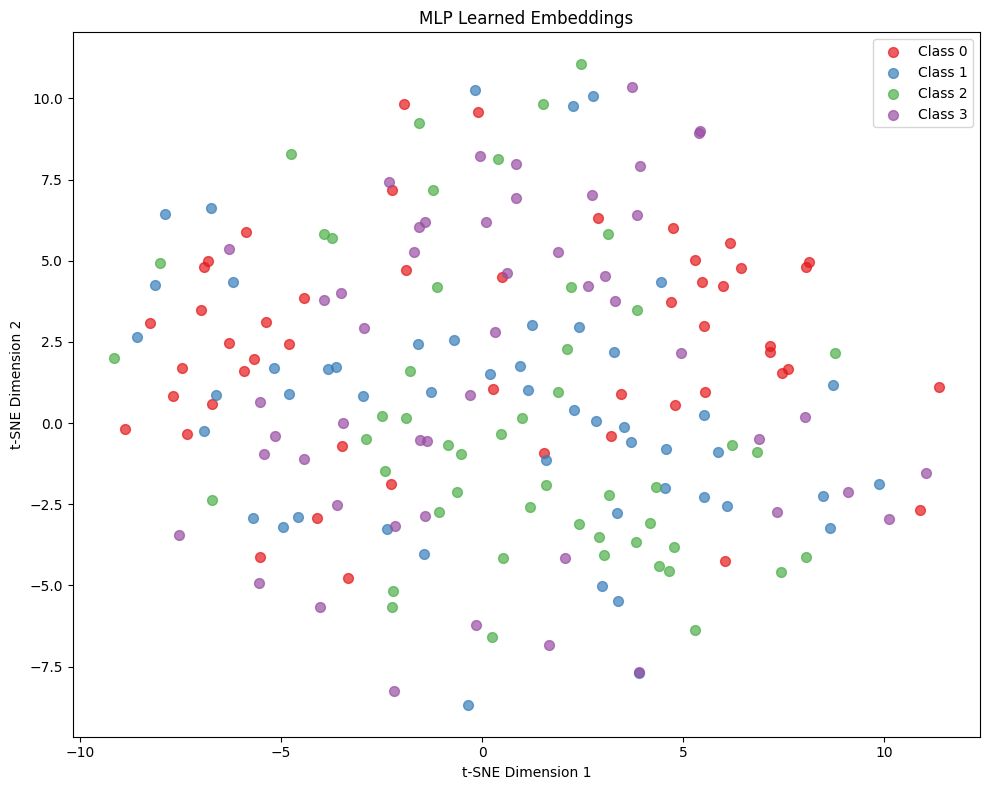

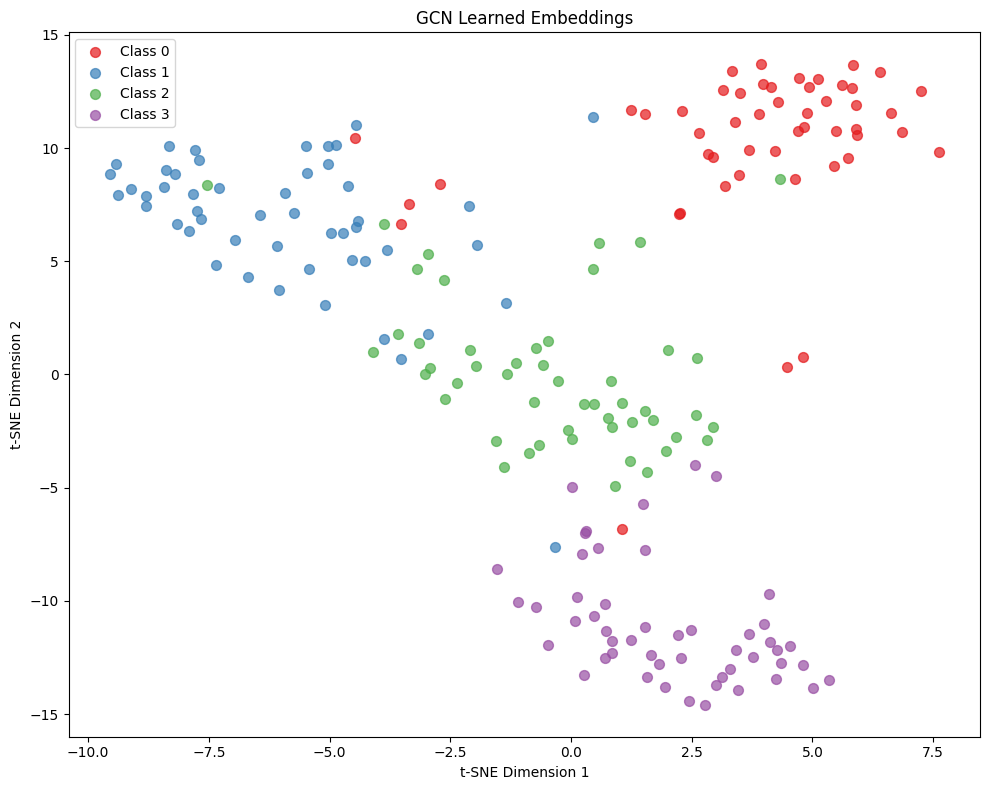

In [55]:
@torch.no_grad()
def get_embeddings(model, data):
    """
    Extract node embeddings from the model (before the final layer).
    """
    model.eval()
    
    if isinstance(model, GCN):
        x = model.conv1(data.x, data.edge_index)
        x = F.relu(x)
        return x
    else:
        x = model.fc1(data.x)
        x = F.relu(x)
        return x


# Get embeddings from trained models
mlp = MLP(data.num_node_features, hidden_channels, num_classes)
gcn = GCN(data.num_node_features, hidden_channels, num_classes)

# Train models (using first run masks)
masks = all_masks[0]
_ = run_experiment(mlp, data, masks, num_epochs, lr, weight_decay)
_ = run_experiment(gcn, data, masks, num_epochs, lr, weight_decay)

# Get and visualize embeddings
mlp_emb = get_embeddings(mlp, data)
gcn_emb = get_embeddings(gcn, data)

visualize_embeddings(
    mlp_emb,
    data.y.numpy(),
    "MLP Learned Embeddings",
    "./images/Practice0/mlp_embeddings.png"
)

visualize_embeddings(
    gcn_emb,
    data.y.numpy(),
    "GCN Learned Embeddings",
    "./images/Practice0/gcn_embeddings.png"
)


In [56]:
from torch_geometric.datasets import Planetoid

# Load the Cora dataset
cora_dataset = Planetoid(root = './data', name = 'Cora')
cora_data = cora_dataset[0]

print("Cora Dataset Statistics:")
print(f"  Number of nodes: {cora_data.num_nodes}")
print(f"  Number of edges: {cora_data.num_edges}")
print(f"  Number of features: {cora_data.num_node_features}")
print(f"  Number of classes: {cora_dataset.num_classes}")
print(f"  Has train/val/test masks: {hasattr(cora_data, 'train_mask')}")

Cora Dataset Statistics:
  Number of nodes: 2708
  Number of edges: 10556
  Number of features: 1433
  Number of classes: 7
  Has train/val/test masks: True


In [57]:
# Load the Citeseer dataset
citeseer_dataset = Planetoid(root = './data', name = 'Citeseer')
citeseer_data = citeseer_dataset[0]

print("Citeseer Dataset Statistics:")
print(f"  Number of nodes: {citeseer_data.num_nodes}")
print(f"  Number of edges: {citeseer_data.num_edges}")
print(f"  Number of features: {citeseer_data.num_node_features}")
print(f"  Number of classes: {citeseer_dataset.num_classes}")

Citeseer Dataset Statistics:
  Number of nodes: 3327
  Number of edges: 9104
  Number of features: 3703
  Number of classes: 6


In [58]:
# Create model for Cora
cora_gcn = GCN(
    in_channels = cora_data.num_node_features,
    hidden_channels = 64,
    out_channels = cora_dataset.num_classes
)

# Training setup
optimizer = torch.optim.Adam(cora_gcn.parameters(), lr = 0.01, weight_decay = 5e-4)
criterion = nn.CrossEntropyLoss()

# Training loop
cora_gcn.train()
for epoch in range(200):
    optimizer.zero_grad()
    out = cora_gcn(cora_data.x, cora_data.edge_index)
    loss = criterion(out[cora_data.train_mask], cora_data.y[cora_data.train_mask])
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        cora_gcn.eval()
        pred = cora_gcn(cora_data.x, cora_data.edge_index).argmax(dim = 1)
        
        train_acc = (pred[cora_data.train_mask] == cora_data.y[cora_data.train_mask]).float().mean()
        val_acc = (pred[cora_data.val_mask] == cora_data.y[cora_data.val_mask]).float().mean()
        test_acc = (pred[cora_data.test_mask] == cora_data.y[cora_data.test_mask]).float().mean()
        
        print(f"Epoch {epoch + 1:3d} | Loss: {loss:.4f} | "
              f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")
        cora_gcn.train()

Epoch  50 | Loss: 0.0117 | Train: 1.0000 | Val: 0.7660 | Test: 0.7990
Epoch 100 | Loss: 0.0106 | Train: 1.0000 | Val: 0.7700 | Test: 0.8060
Epoch 150 | Loss: 0.0126 | Train: 1.0000 | Val: 0.7700 | Test: 0.8040
Epoch 200 | Loss: 0.0070 | Train: 1.0000 | Val: 0.7640 | Test: 0.8120
